# 📡 ƯỚC LƯỢNG ĐỘ TRỄ BẰNG TƯƠNG QUAN CHÉO
## Xử lý Tín hiệu Số

---

**Họ và tên:** Nguyễn Văn Giáp
**MSSV:** 102230183 
**Phần phụ trách:** Tạo tín hiệu và ước lượng độ trễ bằng tương quan chéo (Bước 1 & Bước 2)

---

## 📋 Mô tả bài toán

Cho mô hình tín hiệu:

$$r[n] = s[n - D] + w[n]$$

Trong đó:

- $s[n]$ — xung phát chuẩn dạng **tam giác đối xứng**, biên độ đỉnh $A = 1.0$
- $D$ — độ trễ thực tế (số mẫu cần ước lượng)
- $w[n] \sim \mathcal{N}(0, \sigma^2)$ — nhiễu trắng Gauss (AWGN)
- $r[n]$ — tín hiệu thu quan sát được

**Mục tiêu:** Ước lượng $D$ từ $r[n]$ và $s[n]$ với **sai số ≤ 2 ms** (= 16 mẫu tại $f_s = 8000$ Hz).

**Phương pháp:** Tính hàm tương quan chéo $r_{sr}[\ell] = \sum_n s[n] \cdot r[n + \ell]$, rồi tìm đỉnh:

$$\hat{D} = \arg\max_{\ell \geq 0} \; r_{sr}[\ell]$$


---
## Cell 2 — Import thư viện


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import os

%matplotlib inline
plt.rcParams['figure.dpi']  = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

print('[OK] Import thư viện thành công.')
print(f'  NumPy      : {np.__version__}')
print(f'  Matplotlib : {plt.matplotlib.__version__}')


[OK] Import thư viện thành công.
  NumPy      : 2.4.6
  Matplotlib : 3.11.2


---
## Cell 3 — Tham số hệ thống


In [15]:
# ── Tham số hệ thống ─────────────────────────────────────────────────────
FS             = 8000          # Hz — 1 mẫu = 0.125 ms
PULSE_LEN      = 50            # Chiều dài xung mặc định (50 mẫu = 6.25 ms)
TRUE_DELAY     = 200           # Độ trễ thực mặc định (200 mẫu = 25.0 ms)
SIG_LEN        = 500           # Chiều dài tín hiệu thu (62.5 ms)
PEAK_AMPLITUDE = 1.0           # Biên độ đỉnh xung phát

TOLERANCE_MS     = 2.0
TOLERANCE        = int(round(TOLERANCE_MS * FS / 1000.0))  # = 16 mẫu
TOLERANCE_STRICT = 2           # 2 mẫu = 0.25 ms

# ── Dải SNR và Monte Carlo ────────────────────────────────────────────────
SNR_RANGE_DB = np.arange(-15, 16, 1)  # -15 dB → +15 dB
N_TRIALS     = 100
MC_SEED      = 2024

# ── 4 kịch bản kiểm thử theo yêu cầu đề bài ──────────────────────────────
TEST_CASES = {
    'test1': {
        'name': 'Kịch bản 1: SNR cao (Bắt trúng tuyệt đối)',
        'pulse_len': 50, 'true_delay': 200, 'sig_len': 500,
        'snr_db': 10.0,  'seed': 2024,
        'file_name': 'test1.npz', 'fig_name': 'fig1_test1.png',
    },
    'test2': {
        'name': 'Kịch bản 2: SNR thấp (Xê dịch do đỉnh tù)',
        'pulse_len': 50, 'true_delay': 200, 'sig_len': 500,
        'snr_db': -5.0,  'seed': 99,
        'file_name': 'test2.npz', 'fig_name': 'fig2_test2.png',
    },
    'test3': {
        'name': 'Kịch bản 3: Xung dài (Tăng năng lượng Es, đạt trong 2 mẫu)',
        'pulse_len': 80, 'true_delay': 150, 'sig_len': 600,
        'snr_db': 5.0,   'seed': 101,
        'file_name': 'test3.npz', 'fig_name': 'fig3_test3.png',
    },
    'test4': {
        'name': 'Kịch bản 4: Xung ngắn, SNR cực thấp (Đỉnh giả ở xa)',
        'pulse_len': 35, 'true_delay': 280, 'sig_len': 550,
        'snr_db': -10.0, 'seed': 999,
        'file_name': 'test4.npz', 'fig_name': 'fig4_test4.png',
    },
}

# ── Thư mục lưu kết quả ───────────────────────────────────────────────────
BASE_DIR      = os.getcwd()
TEST_DATA_DIR = os.path.join(BASE_DIR, 'test_data')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
os.makedirs(TEST_DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,   exist_ok=True)

print('[OK] Tham số hệ thống:')
print(f'  fs={FS} Hz | PULSE_LEN={PULSE_LEN} | TRUE_DELAY={TRUE_DELAY} ({TRUE_DELAY/FS*1000:.1f} ms)')
print(f'  TOLERANCE={TOLERANCE} mẫu ({TOLERANCE_MS} ms) | TOLERANCE_STRICT={TOLERANCE_STRICT} mẫu')


[OK] Tham số hệ thống:
  fs=8000 Hz | PULSE_LEN=50 | TRUE_DELAY=200 (25.0 ms)
  TOLERANCE=16 mẫu (2.0 ms) | TOLERANCE_STRICT=2 mẫu


---
## Cell 4 — Cơ sở lý thuyết


### 4.1 Xung tam giác đối xứng

Xung phát $s[n]$ chiều dài $M$ mẫu:

$$s[n] = A \cdot \left(1 - \frac{|n - c|}{c}\right), \quad c = \frac{M-1}{2}, \quad n = 0, 1, \ldots, M-1$$

- Với $M$ **chẵn** (vd. $M=50$): $c = 24.5$ → đỉnh thực $\approx 0.9796$ tại $n = 24, 25$
- Với $M$ **lẻ**: đỉnh chính xác $= A$ tại $n = (M-1)/2$

### 4.2 Nhiễu AWGN & Peak SNR

$$\text{Peak SNR (dB)} = 10 \log_{10}\!\left(\frac{A^2}{\sigma^2}\right)
\quad\Rightarrow\quad
\sigma^2 = \frac{A^2}{10^{\text{SNR}/10}}$$

### 4.3 Năng lượng xung tam giác

$$E_s = \sum_{n=0}^{M-1} s^2[n] \approx \frac{M \cdot A^2}{3}$$

*(Xuất phát từ tích phân liên tục của xung tam giác có đáy $M$, biên độ $A$: $\int_{-M/2}^{M/2} A^2(1 - 2|t|/M)^2 dt = \frac{M A^2}{3}$)*

- Với $M = 50, A = 1.0$: $E_s = 16.3265$ (lý thuyết $\approx 50/3 \approx 16.67$)
- Với $M = 80, A = 1.0$: $E_s = 26.3291$ (lý thuyết $\approx 80/3 \approx 26.67$)
- Với $M = 35, A = 1.0$: $E_s = 11.3529$ (lý thuyết $\approx 35/3 \approx 11.67$)

### 4.4 Tương quan chéo (Matched Filtering)

$$r_{sr}[\ell] = \sum_{n} s[n] \cdot r[n + \ell]$$

Khi không có nhiễu: $r_{sr}[\ell] = R_{ss}[\ell - D]$ — đạt cực đại $E_s$ tại $\ell = D$.
Tỷ số SNR đầu ra bộ lọc phối hợp tại đỉnh là $\frac{E_s}{\sigma^2}$.

**Dải lag hợp lệ:** $\ell \in [-(M-1),\; N-1]$ (tổng $M + N - 1$ điểm)


---
## Cell 5 — Các hàm tạo tín hiệu


In [16]:
def generate_triangle_pulse(length: int, amplitude: float = 1.0):
    """
    Tạo xung tam giác đối xứng s[n] có đỉnh = amplitude tại tâm xung.
    length    : số mẫu M
    amplitude : biên độ đỉnh (mặc định 1.0)
    Ghi chú: với M chẵn, tâm tại c=(M-1)/2 là phân số → đỉnh ≈ 0.9796.
    """
    pulse  = np.zeros(length, dtype=float)
    center = (length - 1) / 2.0
    for n in range(length):
        if center > 0:
            val      = amplitude * (1.0 - abs(n - center) / center)
            pulse[n] = max(0.0, val)
        else:
            pulse[n] = amplitude
    return pulse


def create_received_signal(pulse, delay: int, total_len: int):
    """
    Tạo tín hiệu thu lý tưởng r_clean[n] = s[n - D] (không nhiễu).
    pulse     : xung phát s[n]
    delay     : độ trễ D (số mẫu)
    total_len : tổng số mẫu tín hiệu thu
    """
    r_clean   = np.zeros(total_len, dtype=float)
    pulse_len = len(pulse)
    for i in range(pulse_len):
        idx = delay + i
        if 0 <= idx < total_len:
            r_clean[idx] = pulse[i]
    return r_clean


def compute_energy(signal):
    """
    Tính tổng năng lượng Es = sum(|x[n]|^2).
    """
    energy = 0.0
    for val in signal:
        energy += float(val * val)
    return energy


def add_awgn(signal, snr_db: float, peak_amplitude: float = 1.0,
             seed: int = None, rng=None):
    """
    Cộng nhiễu AWGN theo mức Peak SNR.
    sigma^2 = peak_amplitude^2 / 10^(snr_db/10)
    """
    if rng is None:
        rng = np.random.RandomState(seed) if seed is not None else np.random.RandomState()
    sigma2       = (peak_amplitude ** 2) / (10.0 ** (snr_db / 10.0))
    sigma        = np.sqrt(sigma2)
    noise        = rng.randn(len(signal)) * sigma
    noisy_signal = np.zeros(len(signal), dtype=float)
    for i in range(len(signal)):
        noisy_signal[i] = signal[i] + noise[i]
    return noisy_signal


print('[OK] generate_triangle_pulse, create_received_signal, compute_energy, add_awgn')


[OK] generate_triangle_pulse, create_received_signal, compute_energy, add_awgn


---
## Cell 6 — Hàm tính tương quan chéo


In [17]:
def compute_cross_correlation(reference, received):
    """
    Tính r_sr[ell] = sum_n s[n] * r[n + ell].
    Dải lag: -(M-1) ... (N-1)  |  Tổng M+N-1 điểm.
    Trả về: (corr, lags)
    """
    M        = len(reference)
    N        = len(received)
    min_lag  = -(M - 1)
    max_lag  = N - 1
    num_lags = max_lag - min_lag + 1
    lags     = np.zeros(num_lags, dtype=int)
    corr     = np.zeros(num_lags, dtype=float)
    for idx, lag in enumerate(range(min_lag, max_lag + 1)):
        lags[idx] = lag
        n_min = max(0, -lag)
        n_max = min(M - 1, N - 1 - lag)
        if n_min <= n_max:
            s_slice      = reference[n_min : n_max + 1]
            r_slice      = received[n_min + lag : n_max + 1 + lag]
            corr[idx]    = np.sum(s_slice * r_slice)
    return corr, lags


def find_peak_delay(corr, lags):
    """
    Tìm lag >= 0 có giá trị tương quan lớn nhất.
    Trả về D_hat (int) — số mẫu.
    """
    max_val  = -1e30
    best_lag = 0
    for i in range(len(lags)):
        if lags[i] >= 0 and corr[i] > max_val:
            max_val  = corr[i]
            best_lag = lags[i]
    return int(best_lag)


def estimate_delay(reference, received):
    """
    Hàm tích hợp: tính tương quan chéo và trả về D_hat.
    Trả về: (estimated_delay, corr, lags)
    """
    corr, lags      = compute_cross_correlation(reference, received)
    estimated_delay = find_peak_delay(corr, lags)
    return estimated_delay, corr, lags


print('[OK] compute_cross_correlation, find_peak_delay, estimate_delay')


[OK] compute_cross_correlation, find_peak_delay, estimate_delay


---
## Cell 7 — Kiểm chứng hàm tương quan chéo với `np.correlate`

Đối chiếu kết quả hàm `compute_cross_correlation` tự xây dựng với hàm chuẩn `np.correlate(r, s, mode='full')` của NumPy để xác nhận tính chính xác của thuật toán.


In [18]:
# Kiểm chứng với tín hiệu ngẫu nhiên bất kỳ
s_check = generate_triangle_pulse(50, 1.0)
r_check = np.random.RandomState(42).randn(120)

corr_custom, lags_custom = compute_cross_correlation(s_check, r_check)
# np.correlate(r, s, mode='full') tương ứng đúng thứ tự trễ từ -(M-1) đến N-1
corr_numpy = np.correlate(r_check, s_check, mode='full')

max_diff = np.max(np.abs(corr_custom - corr_numpy))
print('=== KIỂM CHỨNG TÍNH ĐÚNG ĐẮN CỦA HÀM TƯƠNG QUAN CHÉO ===')
print(f'  Kích thước mảng kết quả: {len(corr_custom)} điểm lag')
print(f'  Sai khác cực đại |custom - numpy| = {max_diff:.2e}')

assert max_diff < 1e-12, 'Lỗi: Tương quan chéo tự code không khớp với chuẩn NumPy!'
print('  [XÁC NHẬN] Thuật toán tự xây dựng chính xác theo đúng định nghĩa toán học.')


=== KIỂM CHỨNG TÍNH ĐÚNG ĐẮN CỦA HÀM TƯƠNG QUAN CHÉO ===
  Kích thước mảng kết quả: 169 điểm lag
  Sai khác cực đại |custom - numpy| = 1.78e-15
  [XÁC NHẬN] Thuật toán tự xây dựng chính xác theo đúng định nghĩa toán học.


---
## Cell 8 — Hàm tính sai số


In [19]:
def compute_error(estimated_delay: int, true_delay: int) -> int:
    """
    Sai số tuyệt đối |D_hat - D| (số mẫu).
    """
    return abs(estimated_delay - true_delay)


print('[OK] compute_error')


[OK] compute_error


---
## Cell 9 — Dạng xung s[n] và năng lượng Es


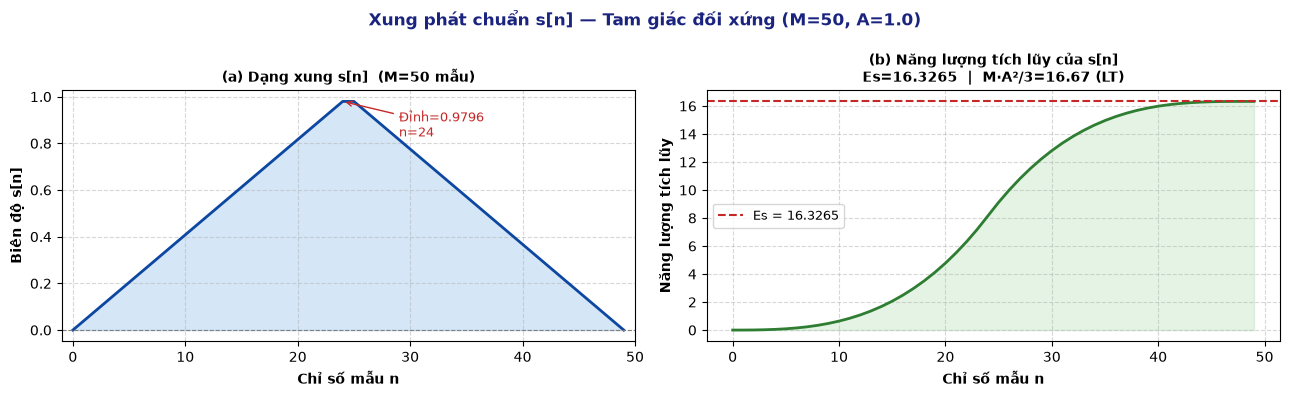


[Kết quả] Xung tam giác M=50:
  Biên độ đỉnh thực = 0.979592  (A=1.0)
  Năng lượng Es     = 16.3265  (LT ≈ M·A²/3 = 16.67)
  Chiều dài hữu ích ≈ 48 mẫu (s[0]=s[M-1]≈0)


In [20]:
# Tạo xung mặc định M=50
s_default = generate_triangle_pulse(PULSE_LEN, amplitude=PEAK_AMPLITUDE)
Es        = compute_energy(s_default)
n_axis    = np.arange(PULSE_LEN)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Xung phát chuẩn s[n] — Tam giác đối xứng'
             f' (M={PULSE_LEN}, A={PEAK_AMPLITUDE})',
             fontsize=12, fontweight='bold', color='#1A237E')

# (a) Dạng xung
ax = axes[0]
ax.plot(n_axis, s_default, color='#0D47A1', linewidth=2.0)
ax.fill_between(n_axis, s_default, alpha=0.18, color='#1976D2')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Chỉ số mẫu n', fontsize=10, fontweight='bold')
ax.set_ylabel('Biên độ s[n]', fontsize=10, fontweight='bold')
ax.set_title(f'(a) Dạng xung s[n]  (M={PULSE_LEN} mẫu)',
             fontsize=10, fontweight='bold')
ax.set_xlim(-1, PULSE_LEN)
ax.grid(True, linestyle='--', alpha=0.5)
peak_n = int(np.argmax(s_default))
ax.annotate(f'Đỉnh={max(s_default):.4f}\nn={peak_n}',
            xy=(peak_n, max(s_default)),
            xytext=(peak_n + 5, max(s_default) - 0.15),
            arrowprops=dict(arrowstyle='->', color='#C62828'),
            fontsize=9, color='#C62828')

# (b) Năng lượng tích lũy
ax2 = axes[1]
cum_Es = np.cumsum(s_default ** 2)
ax2.plot(n_axis, cum_Es, color='#2E7D32', linewidth=2.0)
ax2.fill_between(n_axis, cum_Es, alpha=0.15, color='#4CAF50')
ax2.axhline(Es, color='#C62828', linestyle='--', linewidth=1.5,
            label=f'Es = {Es:.4f}')
ax2.set_xlabel('Chỉ số mẫu n', fontsize=10, fontweight='bold')
ax2.set_ylabel('Năng lượng tích lũy', fontsize=10, fontweight='bold')
ax2.set_title(f'(b) Năng lượng tích lũy của s[n]\n'
              f'Es={Es:.4f}  |  M·A²/3={PULSE_LEN*PEAK_AMPLITUDE**2/3:.2f} (LT)',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'fig0_pulse_energy.png'),
            dpi=130, bbox_inches='tight')
plt.show()

print(f'\n[Kết quả] Xung tam giác M={PULSE_LEN}:')
print(f'  Biên độ đỉnh thực = {max(s_default):.6f}  (A={PEAK_AMPLITUDE})')
print(f'  Năng lượng Es     = {Es:.4f}  (LT ≈ M·A²/3 = {PULSE_LEN/3:.2f})')
print(f'  Chiều dài hữu ích ≈ {PULSE_LEN-2} mẫu (s[0]=s[M-1]≈0)')


---
## Cell 10 — Hàm vẽ đồ thị phân tích 3 tầng


In [21]:
def plot_test_case_figure(test_id, test_name, s, r_noisy, corr, lags,
                          true_delay, est_delay, snr_db,
                          fs=8000.0, tolerance=16, save_path=None):
    """
    Vẽ đồ thị phân tích 3 tầng:
      (a) Xung phát s[n]
      (b) Tín hiệu thu r[n]
      (c) Hàm tương quan chéo r_sr[ell] với đỉnh D_hat
    """
    fig, axes = plt.subplots(3, 1, figsize=(10.5, 6.2),
                             gridspec_kw={'height_ratios': [1.0, 1.0, 1.45]})
    fig.patch.set_facecolor('#FAFAFA')

    err_s    = abs(est_delay - true_delay)
    err_ms   = (err_s    / fs) * 1000.0
    true_ms  = (true_delay / fs) * 1000.0
    est_ms   = (est_delay  / fs) * 1000.0
    is_hit   = err_s <= tolerance
    s_txt    = 'V DAT (<= 2.0 ms)' if is_hit else 'X THAT BAI (> 2.0 ms)'
    s_col    = '#2E7D32' if is_hit else '#C62828'

    fig.suptitle(
        f'{test_id.upper()}: {test_name}\n'
        f'SNR={snr_db:+.1f} dB  |  D={true_delay} ({true_ms:.2f} ms)  |  '
        f'D_hat={est_delay} ({est_ms:.2f} ms)  |  '
        f'Sai so={err_s} mau ({err_ms:.2f} ms)  [{s_txt}]',
        fontsize=8.8, fontweight='bold', color='#1A237E', y=0.985)

    # (a) Xung phát
    ax1 = axes[0]; ax1.set_facecolor('#FFFFFF')
    n_s = np.arange(len(s))
    ax1.plot(n_s, s, color='#0D47A1', linewidth=1.8, label=f's[n] (M={len(s)})')
    ax1.fill_between(n_s, s, alpha=0.18, color='#1976D2')
    ax1.set_xlabel('Chi so mau n', fontsize=8, fontweight='bold')
    ax1.set_ylabel('Bien do s[n]', fontsize=8, fontweight='bold')
    ax1.set_title('(a) Tin hieu phat chuan s[n] (Xung tam giac doi xung)',
                  fontsize=8.5, fontweight='bold', loc='left', pad=2)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper right', fontsize=7.5, framealpha=0.85)

    # (b) Tín hiệu thu
    ax2 = axes[1]; ax2.set_facecolor('#FFFFFF')
    n_r = np.arange(len(r_noisy))
    ax2.plot(n_r, r_noisy, color='#546E7A', linewidth=0.9, alpha=0.85, label='r[n]')
    ax2.axvspan(true_delay, min(true_delay + len(s), len(r_noisy)),
                color='#4CAF50', alpha=0.22,
                label=f'Xung thuc [{true_delay}, {true_delay+len(s)}]')
    ax2.set_xlabel('Chi so mau n', fontsize=8, fontweight='bold')
    ax2.set_ylabel('Bien do r[n]', fontsize=8, fontweight='bold')
    ax2.set_title(f'(b) Tin hieu thu r[n]=s[n-D]+w[n]  (SNR={snr_db:+.1f} dB)',
                  fontsize=8.5, fontweight='bold', loc='left', pad=2)
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='upper right', fontsize=7.5, framealpha=0.85)

    # (c) Tương quan chéo
    ax3 = axes[2]; ax3.set_facecolor('#FFFFFF')
    ax3.plot(lags, corr, color='#D84315', linewidth=1.4, label='r_sr[ell]')
    idx_e    = np.where(lags == est_delay)[0]
    peak_val = corr[idx_e[0]] if len(idx_e) > 0 else np.max(corr)
    ax3.axvline(true_delay, color='#2E7D32', linestyle='--', linewidth=1.5,
                alpha=0.85, label=f'Tre thuc D={true_delay}')
    ax3.plot(est_delay, peak_val, 'o', color=s_col, markersize=7,
             markeredgecolor='black', markeredgewidth=1.2,
             label=f'Dinh D_hat={est_delay}', zorder=5)
    ax3.set_xlabel('Do lech lag ell (mau)', fontsize=8.5, fontweight='bold')
    ax3.set_ylabel('r_sr[ell]', fontsize=8.5, fontweight='bold')
    ax3.set_title('(c) Tuong quan cheo va vi tri dinh uoc luong D_hat',
                  fontsize=8.5, fontweight='bold', loc='left', pad=2)
    ax3.set_xlim(min(lags), max(lags))
    ax3.margins(y=0.20)
    ax3.grid(True, linestyle='--', alpha=0.5)
    lag_mid = (min(lags) + max(lags)) / 2.0
    ax3.legend(loc='upper left' if est_delay > lag_mid else 'upper right',
               fontsize=7.5, framealpha=0.9)

    plt.tight_layout(rect=[0.01, 0.01, 0.99, 0.95])
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
    return fig


print('[OK] plot_test_case_figure')


[OK] plot_test_case_figure


---
## Cell 11 — Vòng lặp 4 kịch bản kiểm thử: tạo tín hiệu, ước lượng D̂, in bảng và vẽ đồ thị


  BUOC 1+2: TAO DU LIEU, UOC LUONG DO TRE, VE FIG1-FIG4

Test   |     SNR |     M |       D thuc |        D_hat |     Sai so | Ket qua
-----------------------------------------------------------------------------
test1  |  +10.0 dB |    50 |   200 (25.00 ms) |   200 (25.00 ms) |   0 ( 0.00 ms) | BAT TRUNG TUYET DOI (D_hat = D)


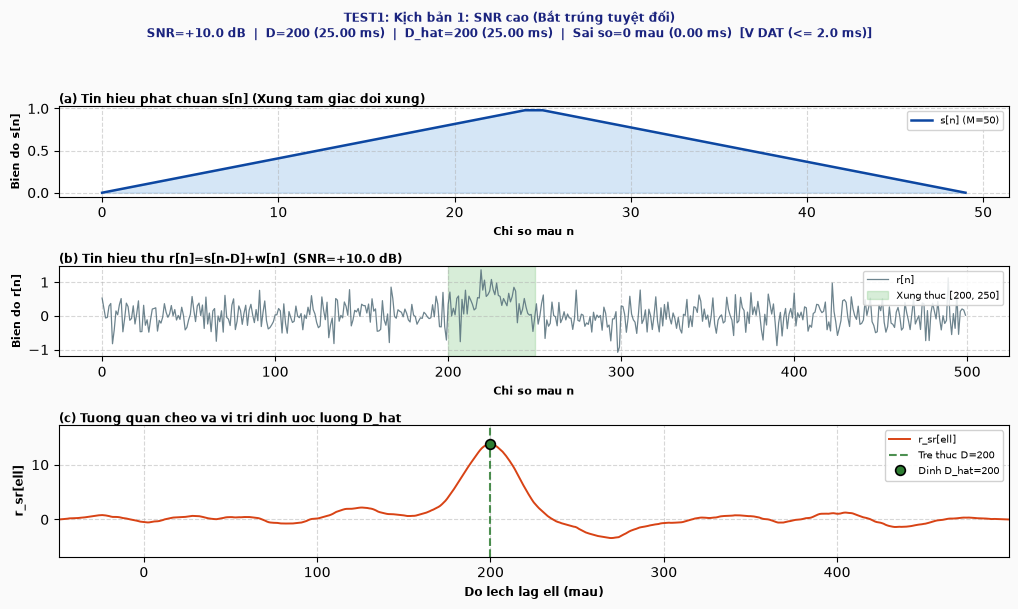

  [OK] Hinh luu: e:\XLTHS\Cross-Correlation\results\fig1_test1.png
test2  |   -5.0 dB |    50 |   200 (25.00 ms) |   195 (24.38 ms) |   5 ( 0.62 ms) | DAT DUNG SAI (5 mau / 0.62 ms <= 2.0 ms)


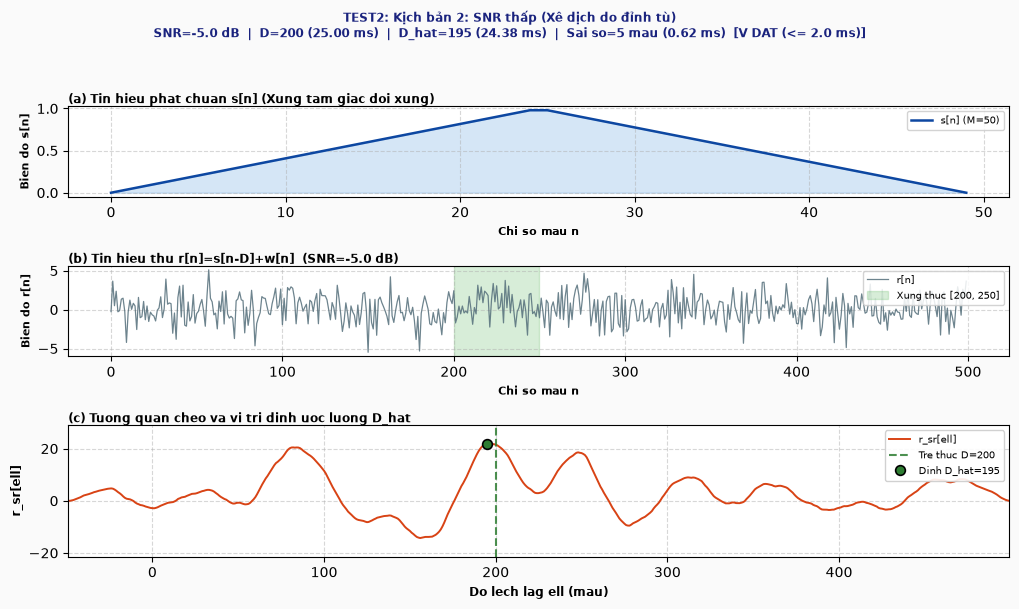

  [OK] Hinh luu: e:\XLTHS\Cross-Correlation\results\fig2_test2.png
test3  |   +5.0 dB |    80 |   150 (18.75 ms) |   152 (19.00 ms) |   2 ( 0.25 ms) | DAT CHINH XAC (lech 2 mau <= 2 mau)


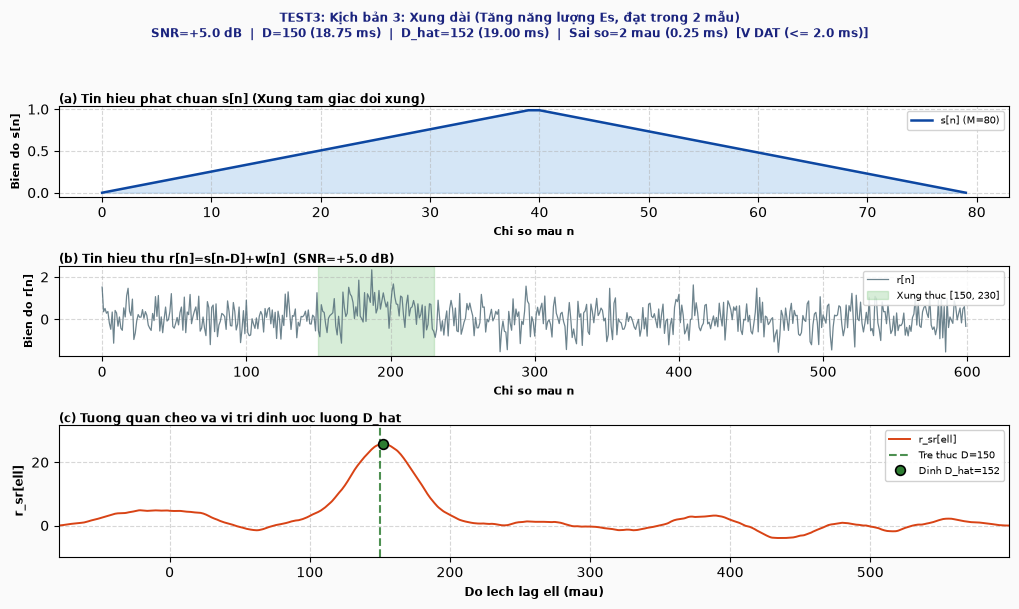

  [OK] Hinh luu: e:\XLTHS\Cross-Correlation\results\fig3_test3.png
test4  |  -10.0 dB |    35 |   280 (35.00 ms) |   495 (61.88 ms) | 215 (26.88 ms) | THAT BAI (215 mau / 26.88 ms > 2.0 ms — Dinh gia)


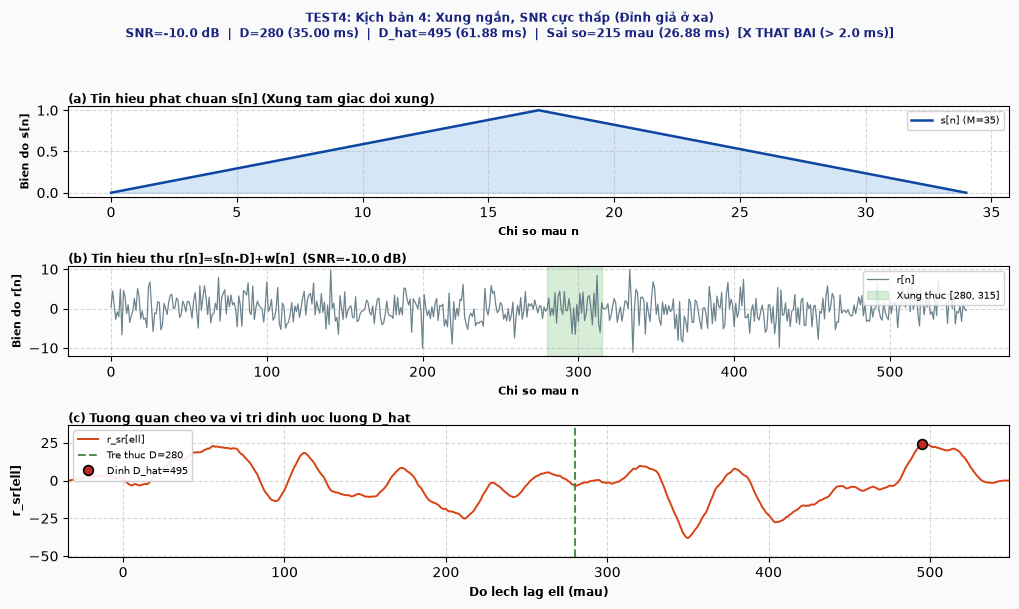

  [OK] Hinh luu: e:\XLTHS\Cross-Correlation\results\fig4_test4.png

[OK] Hoan tat 4 kich ban.


In [22]:
print('=' * 72)
print('  BUOC 1+2: TAO DU LIEU, UOC LUONG DO TRE, VE FIG1-FIG4')
print('=' * 72)

header = (f"{'Test':6s} | {'SNR':>7s} | {'M':>5s} | {'D thuc':>12s} | "
          f"{'D_hat':>12s} | {'Sai so':>10s} | Ket qua")
print('\n' + header)
print('-' * len(header))

results_summary = []

for key, cfg in TEST_CASES.items():
    # Bước 1: Tạo tín hiệu
    s       = generate_triangle_pulse(cfg['pulse_len'], amplitude=PEAK_AMPLITUDE)
    r_clean = create_received_signal(s, cfg['true_delay'], cfg['sig_len'])
    r_noisy = add_awgn(r_clean, cfg['snr_db'],
                       peak_amplitude=PEAK_AMPLITUDE, seed=cfg['seed'])
    Es      = compute_energy(s)

    # Bước 2: Ước lượng độ trễ
    est_D, corr, lags = estimate_delay(s, r_noisy)
    err     = compute_error(est_D, cfg['true_delay'])
    err_ms  = (err             / FS) * 1000.0
    true_ms = (cfg['true_delay'] / FS) * 1000.0
    est_ms  = (est_D           / FS) * 1000.0

    if err == 0:
        res_str = 'BAT TRUNG TUYET DOI (D_hat = D)'
    elif err <= TOLERANCE_STRICT:
        res_str = f'DAT CHINH XAC (lech {err} mau <= 2 mau)'
    elif err <= TOLERANCE:
        res_str = f'DAT DUNG SAI ({err} mau / {err_ms:.2f} ms <= 2.0 ms)'
    else:
        res_str = f'THAT BAI ({err} mau / {err_ms:.2f} ms > 2.0 ms — Dinh gia)'

    print(f"{key:6s} | {cfg['snr_db']:>+6.1f} dB | {cfg['pulse_len']:>5d} | "
          f"{cfg['true_delay']:>5d} ({true_ms:5.2f} ms) | "
          f"{est_D:>5d} ({est_ms:5.2f} ms) | "
          f"{err:>3d} ({err_ms:5.2f} ms) | {res_str}")

    # Vẽ và lưu hình
    fig_path = os.path.join(RESULTS_DIR, cfg['fig_name'])
    fig = plot_test_case_figure(
        test_id=key, test_name=cfg['name'],
        s=s, r_noisy=r_noisy, corr=corr, lags=lags,
        true_delay=cfg['true_delay'], est_delay=est_D,
        snr_db=cfg['snr_db'], fs=FS, tolerance=TOLERANCE,
        save_path=fig_path
    )
    plt.show()
    plt.close(fig)
    print(f'  [OK] Hinh luu: {fig_path}')

    results_summary.append(dict(
        key=key, cfg=cfg, s=s, r_clean=r_clean, r_noisy=r_noisy,
        corr=corr, lags=lags, est_D=est_D,
        err=err, err_ms=err_ms, Es=Es
    ))

print('\n[OK] Hoan tat 4 kich ban.')


---
## Cell 12 — Lưu và đọc kiểm tra dữ liệu kiểm thử (.npz)


In [23]:
def save_test_data(filepath: str, data_dict: dict):
    """Lưu dữ liệu kiểm thử ra tệp .npz nén."""
    if filepath.endswith('.npz'):
        np.savez_compressed(filepath, **data_dict)
    else:
        np.save(filepath, data_dict, allow_pickle=True)


def load_test_data(filepath: str) -> dict:
    """Đọc dữ liệu kiểm thử từ tệp .npz."""
    if filepath.endswith('.npz'):
        with np.load(filepath, allow_pickle=False) as loaded:
            res = {}
            for k in loaded.files:
                val    = loaded[k]
                res[k] = val.item() if val.ndim == 0 else val
        return res
    return np.load(filepath, allow_pickle=True).item()


# Lưu 4 bộ dữ liệu
print('Lưu 4 bộ dữ liệu kiểm thử vào test_data/ ...')
for rec in results_summary:
    cfg      = rec['cfg']
    s        = rec['s']
    data_dict = {
        's': s, 'r_clean': rec['r_clean'], 'r_noisy': rec['r_noisy'],
        'true_delay': cfg['true_delay'], 'snr_db': cfg['snr_db'],
        'pulse_len': cfg['pulse_len'],   'sig_len': cfg['sig_len'],
        'seed': cfg['seed'],
    }
    fp = os.path.join(TEST_DATA_DIR, cfg['file_name'])
    save_test_data(fp, data_dict)
    print(f'  [OK] {fp}')

# Kiểm tra đọc lại test1
print('\nKiem tra doc lai test1.npz:')
loaded = load_test_data(os.path.join(TEST_DATA_DIR, 'test1.npz'))
print(f'  Keys       : {list(loaded.keys())}')
print(f'  true_delay = {loaded["true_delay"]}  |  snr_db = {loaded["snr_db"]}')
print(f'  s.shape    = {loaded["s"].shape}  |  r_noisy.shape = {loaded["r_noisy"].shape}')
print('[OK] Luu / doc .npz thanh cong.')


Lưu 4 bộ dữ liệu kiểm thử vào test_data/ ...
  [OK] e:\XLTHS\Cross-Correlation\test_data\test1.npz
  [OK] e:\XLTHS\Cross-Correlation\test_data\test2.npz
  [OK] e:\XLTHS\Cross-Correlation\test_data\test3.npz
  [OK] e:\XLTHS\Cross-Correlation\test_data\test4.npz

Kiem tra doc lai test1.npz:
  Keys       : ['s', 'r_clean', 'r_noisy', 'true_delay', 'snr_db', 'pulse_len', 'sig_len', 'seed']
  true_delay = 200  |  snr_db = 10.0
  s.shape    = (50,)  |  r_noisy.shape = (500,)
[OK] Luu / doc .npz thanh cong.


---
## Cell 13 — Bảng chỉ số trung gian định lượng cho 4 kịch bản kiểm thử

Bảng tổng hợp đối chiếu định lượng giữa các thông số cốt lõi:
- $r_{sr}[\hat{D}]$: Giá trị tương quan tại đỉnh ước lượng
- $r_{sr}[D]$: Giá trị tương quan tại đỉnh thực tế
- **Đỉnh cục bộ 2 (cách >2 mẫu):** Lag và biên độ của đỉnh cục bộ lớn thứ hai trên hàm tương quan
- Độ lệch chuẩn nhiễu $\sigma$ và Tỷ số $E_s / \sigma^2$ (SNR đầu ra bộ lọc phối hợp)


In [24]:
print('=' * 115)
print('  BẢNG CHỈ SỐ TRUNG GIAN ĐỊNH LƯỢNG CHO TỪNG TEST CASE')
print('=' * 115)

hdr = (f"{'Test':6s} | {'SNR':>7s} | {'M':>3s} | {'D':>4s} | {'D_hat':>5s} | {'Sai số':>7s} | "
       f"{'r_sr[D_hat]':>11s} | {'r_sr[D]':>9s} | {'Đỉnh cục bộ 2 (>2 mẫu)':>24s} | {'sigma':>6s} | {'Es/sigma^2':>13s} | Đánh giá")
print(hdr)
print('-' * len(hdr))

for rec in results_summary:
    key  = rec['key']
    cfg  = rec['cfg']
    corr = rec['corr']
    lags = rec['lags']
    d_hat = rec['est_D']
    d_true = cfg['true_delay']
    
    idx_hat = np.where(lags == d_hat)[0][0]
    idx_true = np.where(lags == d_true)[0][0]
    val_hat = corr[idx_hat]
    val_true = corr[idx_true]
    
    # Tìm đỉnh cực đại địa phương lớn thứ 2 (cách đỉnh chính > 2 mẫu)
    valid_mask = lags >= 0
    v_lags = lags[valid_mask]
    v_corr = corr[valid_mask]
    loc_max_lags, loc_max_vals = [], []
    for i in range(1, len(v_corr) - 1):
        if v_corr[i] > v_corr[i-1] and v_corr[i] >= v_corr[i+1]:
            loc_max_lags.append(v_lags[i])
            loc_max_vals.append(v_corr[i])
            
    sec_lag, sec_val = None, -1e9
    for l_lag, l_val in zip(loc_max_lags, loc_max_vals):
        if abs(l_lag - d_hat) > 2:
            if l_val > sec_val:
                sec_val = l_val
                sec_lag = l_lag
    sec_str = f'lag={sec_lag:3d} (r={sec_val:6.2f})' if sec_lag is not None else 'N/A'
    
    sigma2 = (PEAK_AMPLITUDE ** 2) / (10.0 ** (cfg['snr_db'] / 10.0))
    sigma  = np.sqrt(sigma2)
    mf_snr = rec['Es'] / sigma2
    mf_snr_db = 10.0 * np.log10(mf_snr)
    
    eval_str = ('Bắt trúng tuyệt đối' if rec['err'] == 0 else
                f'Đạt (lệch {rec["err"]} mẫu)' if rec['err'] <= TOLERANCE else 'Thất bại (đỉnh giả)')
    
    print(f"{key:6s} | {cfg['snr_db']:>+6.1f} dB | {cfg['pulse_len']:>3d} | {d_true:>4d} | {d_hat:>5d} | "
          f"{rec['err']:>3d} ({rec['err_ms']:4.2f}ms) | "
          f"{val_hat:>11.4f} | {val_true:>9.4f} | {sec_str:>24s} | {sigma:>6.4f} | "
          f"{mf_snr:6.2f} ({mf_snr_db:+5.1f}dB) | {eval_str}")
print('=' * 115)


  BẢNG CHỈ SỐ TRUNG GIAN ĐỊNH LƯỢNG CHO TỪNG TEST CASE
Test   |     SNR |   M |    D | D_hat |  Sai số | r_sr[D_hat] |   r_sr[D] |   Đỉnh cục bộ 2 (>2 mẫu) |  sigma |    Es/sigma^2 | Đánh giá
----------------------------------------------------------------------------------------------------------------------------------------
test1  |  +10.0 dB |  50 |  200 |   200 |   0 (0.00ms) |     13.7654 |   13.7654 |       lag=126 (r=  2.17) | 0.3162 | 163.27 (+22.1dB) | Bắt trúng tuyệt đối
test2  |   -5.0 dB |  50 |  200 |   195 |   5 (0.62ms) |     21.7589 |   21.5020 |       lag=198 (r= 21.74) | 1.7783 |   5.16 ( +7.1dB) | Đạt (lệch 5 mẫu)
test3  |   +5.0 dB |  80 |  150 |   152 |   2 (0.25ms) |     25.7578 |   25.6312 |       lag=  6 (r=  4.62) | 0.5623 |  83.26 (+19.2dB) | Đạt (lệch 2 mẫu)
test4  |  -10.0 dB |  35 |  280 |   495 | 215 (26.88ms) |     24.1343 |   -3.0053 |       lag= 56 (r= 22.89) | 3.1623 |   1.14 ( +0.6dB) | Thất bại (đỉnh giả)


---
## Cell 14 — Bảng giá trị tương quan lân cận đỉnh $\ell \in [D-3, D+3]$ & Đối chiếu $R_{ss}$ lý thuyết

Minh họa tính chất **đỉnh tù (flat top)** của hàm tự tương quan xung tam giác:
Tại tâm đỉnh, $R_{ss}(0) - R_{ss}(\pm 1) \approx 0.04$ (với $M=50$), mức chênh lệch cực kỳ nhỏ.
Do đó, khi có nhiễu, thành phần ngẫu nhiên dễ làm dịch chuyển vị trí cực đại đi vài mẫu.


In [25]:
print('=== ĐỐI CHIẾU GIÁ TRỊ LÂN CẬN ĐỈNH [D-3 ... D+3] VỚI TỰ TƯƠNG QUAN LÝ THUYẾT R_ss ===')

for rec in results_summary[:3]:  # Xem Test 1, 2, 3
    key    = rec['key']
    cfg    = rec['cfg']
    s      = rec['s']
    corr   = rec['corr']
    lags   = rec['lags']
    d_true = cfg['true_delay']
    
    # Tự tương quan lý thuyết không nhiễu R_ss
    r_clean = rec['r_clean']
    r_ss, _ = compute_cross_correlation(s, r_clean)
    
    print(f'\n>> {key.upper()} (SNR = {cfg["snr_db"]:+.1f} dB, M = {cfg["pulse_len"]}, D = {d_true}, D_hat = {rec["est_D"]}):')
    print(f"    {'Lag ell':>8s} | {'Độ lệch':>8s} | {'r_sr[ell] (thực nghiệm)':>23s} | {'R_ss[ell-D] (lý thuyết)':>23s} | {'Đóng góp nhiễu':>16s}")
    print('    ' + '-' * 88)
    for offset in range(-3, 4):
        target_lag = d_true + offset
        idx_c  = np.where(lags == target_lag)[0][0]
        c_val  = corr[idx_c]
        ss_val = r_ss[idx_c]
        noise_contrib = c_val - ss_val
        marker = ' <-- D_hat' if target_lag == rec['est_D'] else (' <-- D_thực' if target_lag == d_true else '')
        print(f"    {target_lag:>8d} | {offset:>+7d}  | {c_val:>23.4f} | {ss_val:>23.4f} | {noise_contrib:>+16.4f}{marker}")


=== ĐỐI CHIẾU GIÁ TRỊ LÂN CẬN ĐỈNH [D-3 ... D+3] VỚI TỰ TƯƠNG QUAN LÝ THUYẾT R_ss ===

>> TEST1 (SNR = +10.0 dB, M = 50, D = 200, D_hat = 200):
     Lag ell |  Độ lệch | r_sr[ell] (thực nghiệm) | R_ss[ell-D] (lý thuyết) |   Đóng góp nhiễu
    ----------------------------------------------------------------------------------------
         197 |      -3  |                 13.4817 |                 15.9817 |          -2.5000
         198 |      -2  |                 13.6450 |                 16.1699 |          -2.5250
         199 |      -1  |                 13.7469 |                 16.2865 |          -2.5397
         200 |      +0  |                 13.7654 |                 16.3265 |          -2.5611 <-- D_hat
         201 |      +1  |                 13.7047 |                 16.2865 |          -2.5818
         202 |      +2  |                 13.5950 |                 16.1699 |          -2.5749
         203 |      +3  |                 13.4423 |                 15.9817 |          -

---
## Cell 15 — Phân tích định lượng chuyên sâu Test 4 (Đỉnh thật $\ell=280$ vs Đỉnh giả $\ell=495$)

So sánh tách biệt giữa thành phần tín hiệu hữu ích và thành phần nhiễu tại hai vị trí lag:


In [26]:
rec4 = results_summary[3]  # Test 4
s4   = rec4['s']
r4_c = rec4['r_clean']
r4_n = rec4['r_noisy']
corr4 = rec4['corr']
lags4 = rec4['lags']
r_ss4, _ = compute_cross_correlation(s4, r4_c)

val_280 = corr4[np.where(lags4 == 280)[0][0]]
val_495 = corr4[np.where(lags4 == 495)[0][0]]
sig_280 = r_ss4[np.where(lags4 == 280)[0][0]]
sig_495 = r_ss4[np.where(lags4 == 495)[0][0]]
noise_280 = val_280 - sig_280
noise_495 = val_495 - sig_495

sigma2_t4 = (PEAK_AMPLITUDE ** 2) / (10.0 ** (-10.0 / 10.0))  # = 10.0
sigma_t4  = np.sqrt(sigma2_t4)                                  # = 3.162
Es_t4     = rec4['Es']                                         # = 11.3529
mf_snr_t4 = Es_t4 / sigma2_t4                                  # = 1.135 (+0.55 dB)
sigma_corr_t4 = np.sqrt(Es_t4 * sigma2_t4)                    # ~ 10.65

print('=' * 85)
print('  PHÂN TÍCH ĐỊNH LƯỢNG TEST 4 (SNR = -10 dB, M = 35 mẫu, D = 280, D_hat = 495)')
print('=' * 85)
print(f'1. Thông số bộ lọc phối hợp:')
print(f'   - Năng lượng xung Es              = {Es_t4:.4f} (LT ≈ 35/3 = 11.67)')
print(f'   - Phương sai nhiễu đầu vào sigma^2 = {sigma2_t4:.4f} (sigma = {sigma_t4:.4f})')
print(f'   - SNR đầu ra Matched Filter Es/sigma^2 = {mf_snr_t4:.4f} ({10*np.log10(mf_snr_t4):+.2f} dB)')
print(f'   - Độ lệch chuẩn nhiễu ở đầu ra tương quan: sigma_corr = sqrt(Es*sigma^2) = {sigma_corr_t4:.4f}')
print(f'   -> Nhận xét: Độ lệch chuẩn nhiễu (10.65) XẤP XỈ biên độ đỉnh tín hiệu lý tưởng (Es = 11.35)!\n')

print(f'2. So sánh tại 2 tọa độ lag:')
print(f"   - Tại đỉnh thật (ell = 280): r_sr[280] = {val_280:+7.4f} | Tín hiệu = {sig_280:7.4f} | Nhiễu = {noise_280:+7.4f}")
print(f"   - Tại đỉnh giả  (ell = 495): r_sr[495] = {val_495:+7.4f} | Tín hiệu = {sig_495:7.4f} | Nhiễu = {noise_495:+7.4f}")
print(f'\n3. Kết luận nguyên nhân thất bại:')
print(f'   Do Es/sigma^2 chỉ còn +0.55 dB, đỉnh tín hiệu thật bị nhiễu âm (-14.36) dìm xuống còn -3.01,')
print(f'   trong khi tại lag 495 nhiễu ngẫu nhiên tạo đỉnh dương (+24.13) vượt qua đỉnh thật.')
print(f'   Đây là hiện tượng Sụp đổ ngưỡng (Threshold Breakdown) kinh điển khi SNR < SNR_th.')
print('=' * 85)


  PHÂN TÍCH ĐỊNH LƯỢNG TEST 4 (SNR = -10 dB, M = 35 mẫu, D = 280, D_hat = 495)
1. Thông số bộ lọc phối hợp:
   - Năng lượng xung Es              = 11.3529 (LT ≈ 35/3 = 11.67)
   - Phương sai nhiễu đầu vào sigma^2 = 10.0000 (sigma = 3.1623)
   - SNR đầu ra Matched Filter Es/sigma^2 = 1.1353 (+0.55 dB)
   - Độ lệch chuẩn nhiễu ở đầu ra tương quan: sigma_corr = sqrt(Es*sigma^2) = 10.6550
   -> Nhận xét: Độ lệch chuẩn nhiễu (10.65) XẤP XỈ biên độ đỉnh tín hiệu lý tưởng (Es = 11.35)!

2. So sánh tại 2 tọa độ lag:
   - Tại đỉnh thật (ell = 280): r_sr[280] = -3.0053 | Tín hiệu = 11.3529 | Nhiễu = -14.3583
   - Tại đỉnh giả  (ell = 495): r_sr[495] = +24.1343 | Tín hiệu =  0.0000 | Nhiễu = +24.1343

3. Kết luận nguyên nhân thất bại:
   Do Es/sigma^2 chỉ còn +0.55 dB, đỉnh tín hiệu thật bị nhiễu âm (-14.36) dìm xuống còn -3.01,
   trong khi tại lag 495 nhiễu ngẫu nhiên tạo đỉnh dương (+24.13) vượt qua đỉnh thật.
   Đây là hiện tượng Sụp đổ ngưỡng (Threshold Breakdown) kinh điển khi SNR < SNR_th.

---
## Cell 16 — Nhận xét chi tiết 4 kịch bản


### Bảng tóm tắt kết quả thực nghiệm

| Kịch bản | SNR (dB) | M (mẫu) | D thực | D ước lượng | Sai số | Kết quả | Nguyên nhân chính |
|:--------:|:--------:|:-------:|:------:|:-----------:|:------:|:-------:|:------------------|
| **Test 1** | +10 | 50 | 200 | 200 | 0 mẫu | ✅ Bắt trúng tuyệt đối | SNR cao ($E_s/\sigma^2 \approx +22.1\text{ dB}$), đỉnh tương quan sắc nét |
| **Test 2** | −5  | 50 | 200 | 195 | 5 mẫu | ⚠️ Đạt dung sai đề bài | Đỉnh tam giác bị tù ($R_{ss}(0)-R_{ss}(\pm 1) \approx 0.04$) → nhiễu làm xê dịch 5 mẫu |
| **Test 3** | +5  | 80 | 150 | 152 | 2 mẫu | ✅ Đạt chính xác trong 2 mẫu | $M=80 \implies E_s \approx 26.33$ tăng Matched Filter SNR lên $+19.2\text{ dB}$ |
| **Test 4** | −10 | 35 | 280 | 495 | 215 mẫu | ❌ Đỉnh giả ở xa | $E_s/\sigma^2 \approx +0.55\text{ dB}$, $\sigma_{\text{corr}} \approx E_s$ → Threshold Breakdown |

---

### 🟢 Test 1 (SNR = +10 dB) — Bắt trúng tuyệt đối

Tại SNR cao (+10 dB), $\sigma = 0.3162 \ll A = 1.0$, tỷ số SNR sau bộ lọc phối hợp đạt $E_s/\sigma^2 = 163.27$ (+22.13 dB).
Nền nhiễu nhỏ hoàn toàn không làm xê dịch đỉnh tương quan $r_{sr}[\ell]$. Vị trí cực đại xác định chính xác tại $\hat{D} = 200$.
Sai số $|\hat{D} - D| = 0$ mẫu — **bắt trúng tuyệt đối**.

### 🟡 Test 2 (SNR = −5 dB) — Xê dịch do đỉnh tù (Flat Top Effect)

Xung tam giác có hàm tự tương quan $R_{ss}[\ell]$ có đỉnh phẳng (tù): chênh lệch giữa tâm đỉnh và 2 mẫu lân cận chỉ là $R_{ss}(0) - R_{ss}(\pm 1) = 16.3265 - 16.2865 = 0.0400$.
Tại SNR = −5 dB, nhiễu $\sigma = 1.7783$ tạo độ thăng giáng ngẫu nhiên lớn hơn độ cong của đỉnh, làm vị trí cực đại $\arg\max$ lệch sang $\hat{D} = 195$ (lệch 5 mẫu).
Đặc biệt, giá trị tại đỉnh ước lượng $r_{sr}[195] = 21.7589$ chỉ nhỉnh hơn đỉnh cục bộ tại $r_{sr}[198] = 21.7399$ khoảng $0.019$ (gần như hòa điểm), chứng minh rõ rệt tính chất bằng phẳng của vùng lân cận đỉnh.
Sai số 5 mẫu (0.625 ms) vẫn nằm trong ngưỡng dung sai đề bài $\le 16$ mẫu (2.0 ms) — **đạt yêu cầu kỹ thuật**.

### 🟢 Test 3 (SNR = +5 dB, M = 80) — Hiệu quả tăng năng lượng $E_s$

Với $M = 80$: $E_s \approx 26.33$ (so với $\approx 16.33$ khi $M=50$, theo công thức $E_s \approx M A^2 / 3$).
Năng lượng xung tăng giúp tỷ số SNR đầu ra bộ lọc phối hợp đạt $+19.2\text{ dB}$, **giảm rất mạnh nguy cơ xuất hiện đỉnh giả** ở xa.
Ước lượng đạt $\hat{D} = 152$, sai số chỉ 2 mẫu (0.25 ms) — **đạt chính xác trong ngưỡng dung sai chặt $\le 2$ mẫu**.

### 🔴 Test 4 (SNR = −10 dB, M = 35) — Đỉnh giả ở xa (Threshold Breakdown)

Xung ngắn $M = 35$ có năng lượng $E_s \approx 11.35$. Tại SNR = −10 dB, phương sai nhiễu $\sigma^2 = 10.0$ khiến SNR đầu ra bộ lọc phối hợp chỉ còn $E_s / \sigma^2 = 1.135$ (**chỉ đạt +0.55 dB**).
Độ lệch chuẩn của nhiễu trong hàm tương quan là $\sigma_{\text{corr}} = \sqrt{E_s \cdot \sigma^2} \approx 10.65$ — **xấp xỉ bằng chính biên độ đỉnh tín hiệu $E_s = 11.35$**.
Do đó, tại đỉnh thật $\ell = 280$, nhiễu âm dìm giá trị xuống $r_{sr}[280] = -3.01$, trong khi tại $\ell = 495$, nhiễu ngẫu nhiên tạo đỉnh dương $r_{sr}[495] = +24.13$.
$\hat{D}$ bị kéo về vị trí đỉnh giả ở xa (lệch 215 mẫu) — **thất bại hoàn toàn do hiện tượng sụp đổ ngưỡng**.


---
## Cell 17 — Tổng kết 4 vùng kết quả & Chuyển giao sang Bước 3 (SV2)

### 📌 Bốn vùng kết quả quan sát được từ Bước 1 & Bước 2:

Qua 4 kịch bản kiểm thử minh họa, ta đã quan sát trực quan 4 hiện tượng vật lý cốt lõi của bài toán ước lượng độ trễ bằng tương quan chéo:

1. **Vùng SNR cao (Test 1, $+10\text{ dB}$):**
   - $E_s/\sigma^2 \gg 1$ ($+22.1\text{ dB}$) → Nền nhiễu không đáng kể, đỉnh tương quan sắc nét, hệ thống **bắt trúng tuyệt đối** ($|\hat{D}-D| = 0$).
2. **Vùng xê dịch do đỉnh tù (Test 2, $-5\text{ dB}$):**
   - Hàm tự tương quan $R_{ss}$ của xung tam giác có đỉnh phẳng ($R_{ss}(0) - R_{ss}(\pm 1) \approx 0.04$). Nhiễu làm dịch vị trí cực đại trong lân cận đỉnh ($5\text{ mẫu} = 0.625\text{ ms}$), vẫn **đạt dung sai đề bài $\le 2.0\text{ ms}$**.
3. **Vùng cải thiện nhờ tăng năng lượng (Test 3, $+5\text{ dB}, M=80$):**
   - Xung dài hơn làm tăng năng lượng $E_s$ ($26.33$ vs $16.33$), tăng SNR sau bộ lọc phối hợp ($+19.2\text{ dB}$), giúp **giảm rất mạnh nguy cơ đỉnh giả** và đạt độ chính xác cao trong dung sai chặt $\le 2\text{ mẫu}$.
4. **Vùng sụp đổ ngưỡng — Threshold Breakdown (Test 4, $-10\text{ dB}, M=35$):**
   - Xung ngắn ở SNR cực thấp khiến $E_s/\sigma^2 \approx +0.55\text{ dB}$. Độ lệch chuẩn nhiễu $\sigma_{\text{corr}} \approx 10.65$ xấp xỉ năng lượng tín hiệu $E_s = 11.35$. Nhiễu ngẫu nhiên tạo đỉnh giả ở xa ($\hat{D}=495$), dẫn đến **ước lượng thất bại hoàn toàn**.

---

### 🔗 Chuyển giao sang Bước 3 (Notebook SV2):

> Bốn kịch bản trên là các ví dụ minh họa trực quan trên từng mẫu thực nghiệm đơn lẻ. Để đánh giá thống kê toàn diện hiệu năng ước lượng của thuật toán, bài toán được chuyển tiếp sang **Bước 3: Đánh giá hiệu năng Monte Carlo** trong notebook [**`monte_carlo_performance.ipynb`**](monte_carlo_performance.ipynb):
>
> - Khảo sát thống kê qua **$31\text{ mức SNR}$ (từ $-15\text{ dB}$ đến $+15\text{ dB}$) $\times 100\text{ lần thử}$** (3.100 lần thử nghiệm độc lập).
> - Đánh giá hai chỉ tiêu định lượng chính: **Tỷ lệ phát hiện đúng (Detection Rate)** với dung sai $\le 2.0\text{ ms}$ và **Sai số toàn phương trung bình (RMSE)** theo SNR.
